# **LABORATORIO 8: ÁRBOLES DE DECISIÓN Y BOSQUES ALEATORIOS**

## **PARTE A: Preparación de los datos**

### **Separación de variables numéricas y no numéricas**

In [1]:
# Importación de librerías
import pandas as pd # Trabajar con datos estructurados
import numpy as np
from IPython.display import display, HTML # Visualización de objetos
import matplotlib.pyplot as plt # Visualización de gráficos
import seaborn as sns # Visualización de gráficos
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Lectura de la data
data = pd.read_csv('cancer.csv')
data.head()

,Unnamed: 0,ClumpThick,UnifCellSize,UnifCellShape,MargAdh,SingEpiCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses,Class
0,0,5,1,1,1,2,1,3,1,1,0
1,1,5,4,4,5,7,10,3,2,1,0
2,2,3,1,1,1,2,2,3,1,1,0
3,3,6,8,8,1,3,4,3,7,1,0
4,4,4,1,1,3,2,1,3,1,1,0


In [3]:
# Eliminacion de primera columna
col = data.columns[0]
data = data.drop(col, axis=1)
data.head()

,ClumpThick,UnifCellSize,UnifCellShape,MargAdh,SingEpiCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


In [4]:
# Se revisan los tipos de datos y valores faltantes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ClumpThick       699 non-null    int64
 1   UnifCellSize     699 non-null    int64
 2   UnifCellShape    699 non-null    int64
 3   MargAdh          699 non-null    int64
 4   SingEpiCellSize  699 non-null    int64
 5   BareNuclei       699 non-null    int64
 6   BlandChromatin   699 non-null    int64
 7   NormalNucleoli   699 non-null    int64
 8   Mitoses          699 non-null    int64
 9   Class            699 non-null    int64
dtypes: int64(10)
memory usage: 54.7 KB


In [5]:
# Se revisan los valores únicos de la variable objetivo 'Class'
data['Class'].unique()

array([0, 1], dtype=int64)

In [6]:
# Se convierte la variable a objetivo a tipo categórica
data['Class'] = data['Class'].astype('category')

In [7]:
# Se separa el dataframe en variables numéricas y no numéricas
data_numeric = data.select_dtypes(include='number')
data_no_numeric = data.select_dtypes(exclude='number')

# Se muestra el dataframe de variables numéricas
display(HTML("<h4>DataFrame de variables numéricas</h4>"))
display(data_numeric.head())

# Se muestra el dataframe de variables no numéricas
display(HTML("<h4>DataFrame de variables no numéricas</h4>"))
display(data_no_numeric.head())

,ClumpThick,UnifCellSize,UnifCellShape,MargAdh,SingEpiCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1


,Class
0,0
1,0
2,0
3,0
4,0


### **Separación en data de entrenamiento y prueba**

In [8]:
from sklearn.model_selection import train_test_split

# Se determina la variable objetivo y las variables predictoras
X = data_numeric # Variables numéricas predictoras
y = data_no_numeric # Variable objetivo categórica

# Se divide la data aleatoriamente en el 75% para el entrenamiento y 25% para la evaluación
# Se asigna un número semilla para la reproducibilidad (random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) 

In [9]:
# Se revisa el balance de las clases en la data de entrenamiento
y_train.value_counts()

Class
0        340
1        184
Name: count, dtype: int64

In [10]:
# Se balancea las clases con muestras sinteticas mediante SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3) # k_neighbors por defecto es 5
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Se revisa el nuevo balance
y_train_smote.value_counts()

Class
0        340
1        340
Name: count, dtype: int64

Se observa que las clases se han balanceado en la misma proporción.

## **PARTE B: Modelo de árbol de decisión**

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Se entrena el modelo de árbol de decisión
max_depth = 5
tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
tree.fit(X_train_smote, y_train_smote)

# Realizar predicciones en el conjunto de prueba
y_pred = tree.predict(X_test)

# Calcular las métricas de clasificación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar las métricas
print("Métricas de Clasificación:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Métricas de Clasificación:
Accuracy:  0.9543
Precision: 0.9153
Recall:    0.9474
F1-score:  0.9310


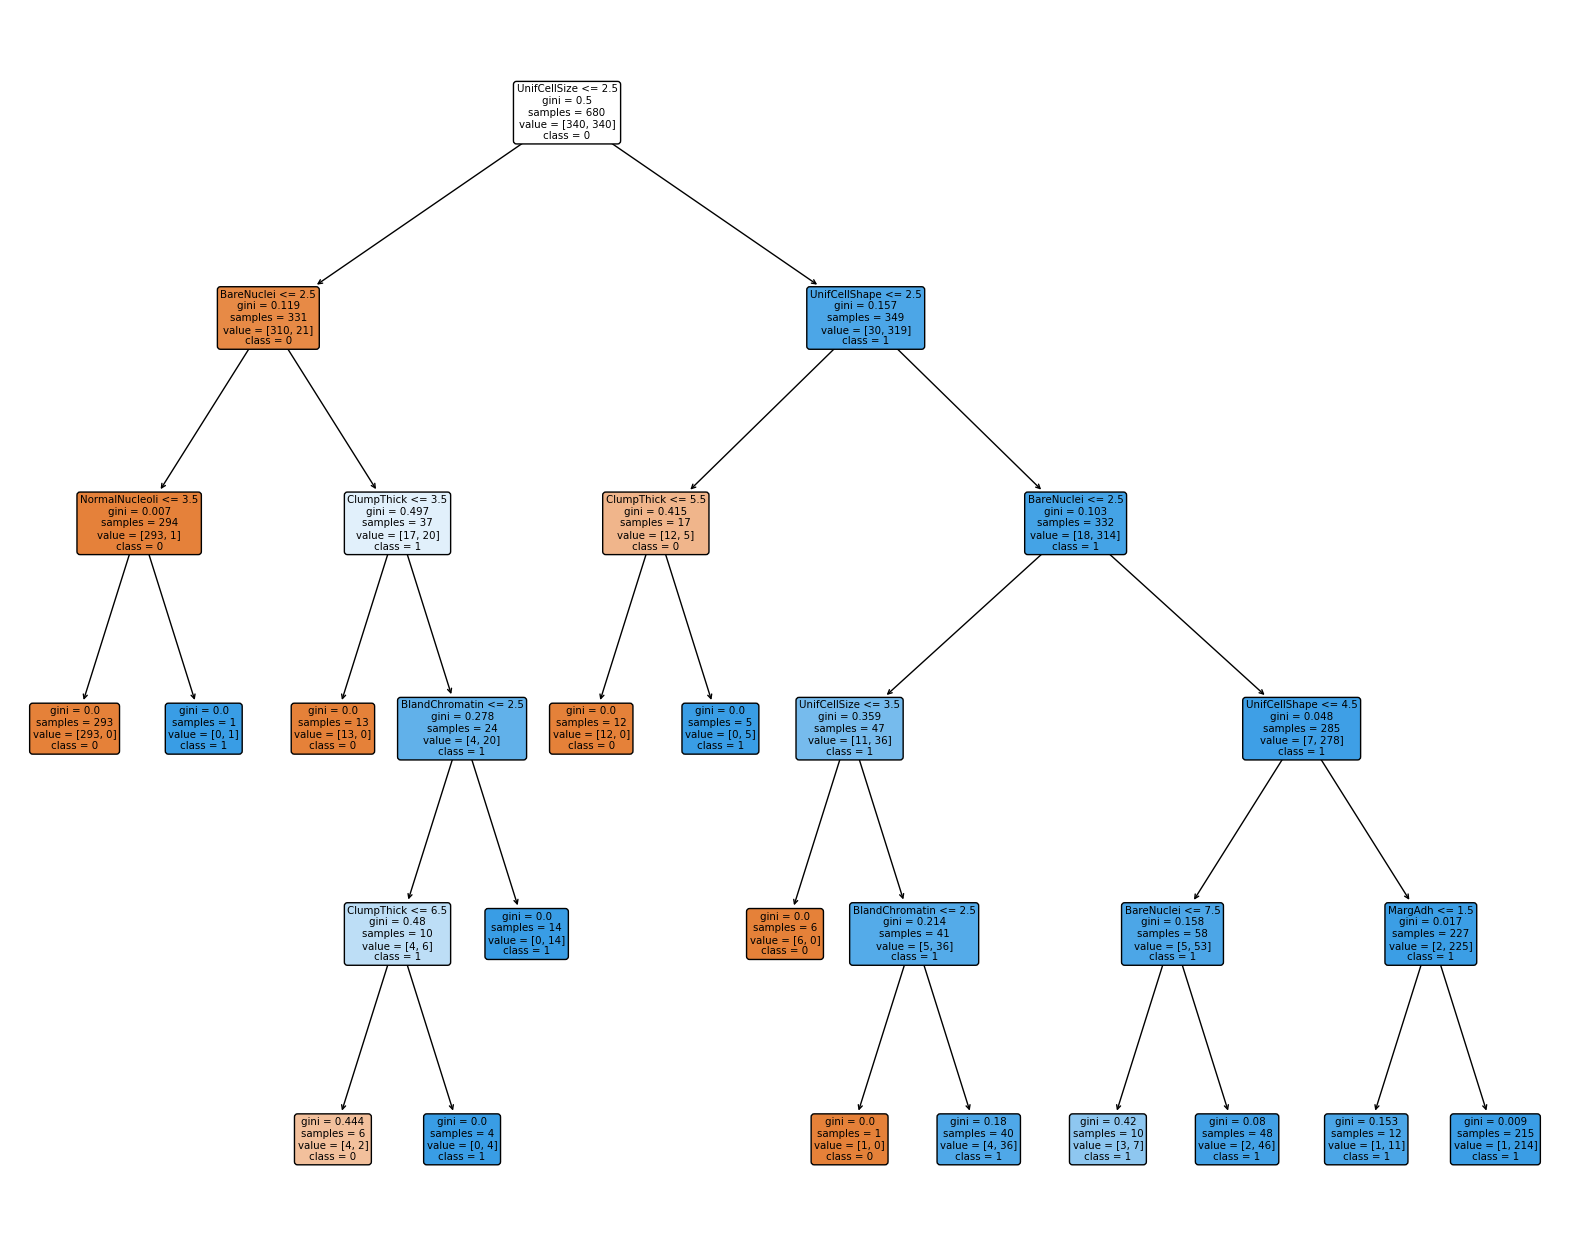

In [16]:
from sklearn.tree import plot_tree

# Se genera la gráfica del arbol de decisión
plt.figure(figsize=(20, 16))

plot_tree(tree,
          feature_names=X_train_smote.columns,
          class_names=[str(c) for c in y_train_smote.iloc[:, 0].unique()],
          filled=True,
          rounded=True)

plt.show()

## **PARTE C: Modelo de bosques aleatorios**

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar el modelo de Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_smote, y_train_smote)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf.predict(X_test)

# Calcular las métricas de clasificación para Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Mostrar las métricas
print("\nMétricas de Clasificación - Árbol de Decisión:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nMétricas de Clasificación - Random Forest:")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")


Métricas de Clasificación - Árbol de Decisión:
Accuracy:  0.9543
Precision: 0.9153
Recall:    0.9474
F1-score:  0.9310

Métricas de Clasificación - Random Forest:
Accuracy:  0.9829
Precision: 0.9500
Recall:    1.0000
F1-score:  0.9744


C:\Users\ACER\AppData\Local\Temp\ipykernel_14476\3623582043.py:5: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(X_train_smote, y_train_smote)


El modelo de Bosques Aleatorios ha obtenido mejores resultados en todas las métricas de evaluación, logrando detectar correctamente todos los casos positivos de células cancerígenas. 